# BTSP in an open field with a corridor (2-comp)

In [27]:
import copy
import time
import warnings

from matplotlib import pyplot as plt
import numpy as np
import ratinabox
from ratinabox import utils as rutils
from tqdm import tqdm

from predhpc import agent, env, run_manager, plot_fcts
from predhpc.neurons import riab_neurons, learning_neurons, two_comp_neurons, object_neurons, value_neurons
from predhpc.util import gen_util, learn_util, params_util, plot_util, animate_util

In [2]:
plot_util.stylize_plots_for_notebook()
ratinabox.autosave_plots = False
ratinabox.figure_directory = "figures"

In [3]:
warnings.filterwarnings(
    "ignore", message="invalid value encountered", 
    category=RuntimeWarning
)

In [31]:
import importlib
importlib.reload(agent)
importlib.reload(env)
importlib.reload(learning_neurons)
importlib.reload(two_comp_neurons)
importlib.reload(object_neurons)
importlib.reload(value_neurons)
importlib.reload(run_manager)
importlib.reload(gen_util)
importlib.reload(learn_util)
importlib.reload(plot_util)
importlib.reload(params_util)
importlib.reload(agent);

## Initialise parameters

In [5]:
RECORD_WEIGHTS_FREQ = 1000
BTSP_LR_FACT = 10 # low factor
ALPHA_REG = 0.3 # lower regularization

env_params = params_util.get_env_params(
    environment="openfield",
    init_random_reward_obj=0,
    init_random_novel_obj=0,
    init_random_walls=0,
    init_random_teleport_pairs=0,
)
start_location = [0.2, 0.8]
reward_location = [0.2, 0.1]
novel_location = [0.9, 0.9]
teleport_in_out = [[0.8, 0.4], [0.1, 0.15]]
wall_coords = [[0, 0.2], [0.6, 0.2]]

agent_params = params_util.get_agent_params(
    environment="openfield",
    reward_factor=10,
    no_target_factor=1,
)

Obj_params = params_util.get_Obj_params(
    environment="openfield",
    num_novel=0,
    num_teleport=0,
    num_reward=1,
    )

PC_params = params_util.get_PC_params(
    environment="openfield",
    n=30**2,
)

VN_params = {
    "n": 1,
    "peak": reward_location,
    "description": "gaussian",
    "max_fr": 10,
    "widths": 0.6,
}

Hebbian_learn = False
Pyr_params = params_util.get_Pyr_params(
    n=1, 
    environment="openfield",
    soma_BTSP_lr_fact=BTSP_LR_FACT,
    soma_regularization_alpha=ALPHA_REG,
)

Target is reward: True.


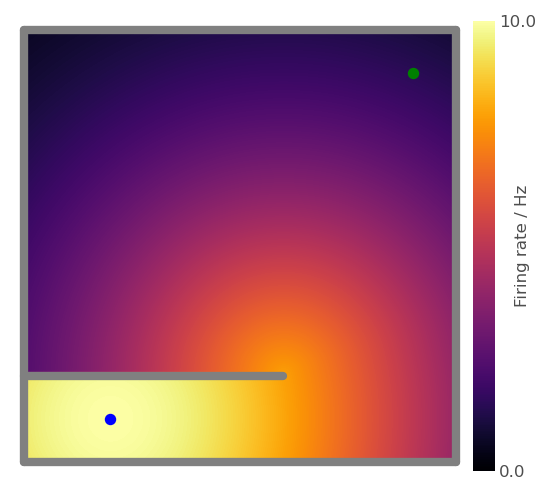

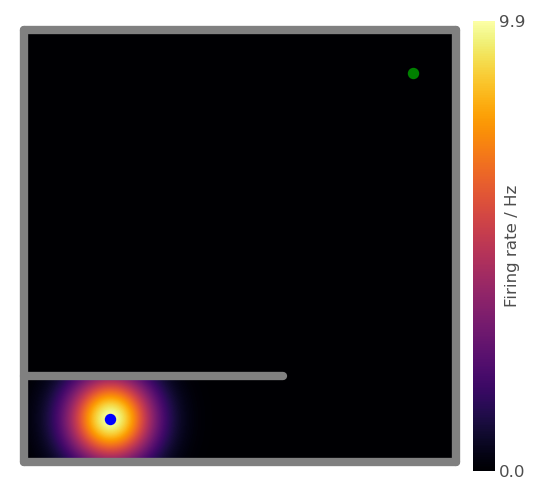

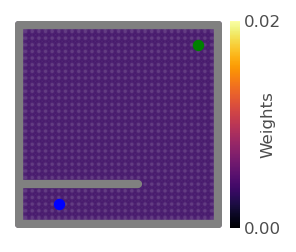

In [6]:
Env = env.OpenField(params=env_params)
Env.add_reward_objects(coords=[reward_location])
Env.add_novel_objects(coords=[novel_location])
Env.add_wall(wall_coords)

Ag = agent.OpenFieldAgent(Env, params=agent_params)
Ag.pos = np.asarray(start_location)
Ag.head_direction = np.asarray([-1, 0])
target_is_reward = Ag.target_position is not None and (Ag.target_position == reward_location).all()
print(f"Target is reward: {target_is_reward}.")

Objs = object_neurons.FixedObjectCells(Ag, params=Obj_params)
PCs = riab_neurons.PlaceCells(Ag, params=PC_params)

Pyr_params["dend_input_layers"] = [Objs]
Pyr_params["soma_input_layers"] = [PCs]
Pyrs = two_comp_neurons.TwoCompLayer(Ag, params=Pyr_params)
Pyrs.set_learn(False)
Pyrs.set_BTSP_learn(False)

VN = value_neurons.SimpleValueNeuron(Ag, params=VN_params)
VN.plot_rate_map(no_legend=True)
Objs.plot_rate_map(no_legend=True)

plot_fcts.plot_2D_input_place_cell_weights(
    Pyrs.SomaCompartment, alpha=0.3, mark_BTSP=False, no_legend=True
);

## Learn

In [7]:
Pyrs.set_learn(soma=Hebbian_learn, dend=False, inhibit=False)
Pyrs.set_BTSP_learn(soma=False, dend=False)

BTSP_started = False
num_BTSP_to_date = len(Pyrs.SomaCompartment.history["BTSP_events"])

Pyrs_weights, Pyrs_weights_t = list(), list()
for i in tqdm(range(15000)):
    VN.update()
    drift_velocity = None
    if Ag.target_position is not None and (Ag.target_position == VN.peak).all():
        gradV = VN.get_local_gradient(thresh_gradV=0.2)
        if gradV is not None: 
            drift_velocity = 3 * Ag.speed_mean * gradV

    Ag.update(
        drift_velocity=drift_velocity,
        drift_to_random_strength_ratio=0.2
        )
    Objs.update()
    PCs.update()
    Pyrs.update()

    if not BTSP_started and len(Ag.trajectory_df) > 2:
        Pyrs.set_BTSP_learn(soma=True, dend=False)
        BTSP_started = True

    if not i % RECORD_WEIGHTS_FREQ:
        Pyrs_weights.append(copy.deepcopy(Pyrs.SomaCompartment.inputs["PCs"]["w"]))
        Pyrs_weights_t.append(Ag.t)

num_BTSP_events = len(Pyrs.SomaCompartment.history["BTSP_events"]) - num_BTSP_to_date

print(f"{num_BTSP_events} BTSP event(s).")
Ag.log_teleportation()
Ag.trajectory_df

100%|████████████████████████████████████| 15000/15000 [00:51<00:00, 289.93it/s]

4 BTSP event(s).
No teleportation events.


,start_position_x,start_position_y,start_step,start_time,stop_position_x,stop_position_y,stop_step,stop_time,num_steps_total,time_total
0,0.531423,0.283512,0,0.0,0.136878,0.107751,2000.0,60.0,2000.0,60.0
1,0.098302,0.778299,2000,60.0,0.341923,0.107751,4000.0,120.0,2000.0,60.0
2,0.047976,0.783056,4000,120.0,0.873730,0.107751,6000.0,180.0,2000.0,60.0
3,0.363621,0.862854,6000,180.0,0.835726,0.107751,8000.0,240.0,2000.0,60.0
4,0.378325,0.644871,8000,240.0,0.434448,0.107751,10000.0,300.0,2000.0,60.0
5,0.448066,0.556527,10000,300.0,0.430267,0.107751,12000.0,360.0,2000.0,60.0
6,0.793438,0.392835,12000,360.0,0.172960,0.107751,14000.0,420.0,2000.0,60.0
7,0.904293,0.645095,14000,420.0,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
Ag.target_df.head()

,object_idx,object_type_name,object_type_num,position_x,position_y,set_step,set_time,random_walk_periods,reached_step,reached_time,num_random_walk_steps,random_walk_time,num_steps_total,time_total
0,0.0,reward,0.0,0.2,0.1,0,0.00,"[[0, 300], [300, 600], [600, 900], [900, 1200]]",1365.0,40.95,1200.0,36.0,1365.0,40.95
1,0.0,reward,0.0,0.2,0.1,1365,40.95,[],1368.0,41.04,0.0,0.0,3.0,0.09
2,0.0,reward,0.0,0.2,0.1,1368,41.04,[],1369.0,41.07,0.0,0.0,1.0,0.03
3,0.0,reward,0.0,0.2,0.1,1369,41.07,[],1370.0,41.10,0.0,0.0,1.0,0.03
4,0.0,reward,0.0,0.2,0.1,1370,41.10,[],1371.0,41.13,0.0,0.0,1.0,0.03


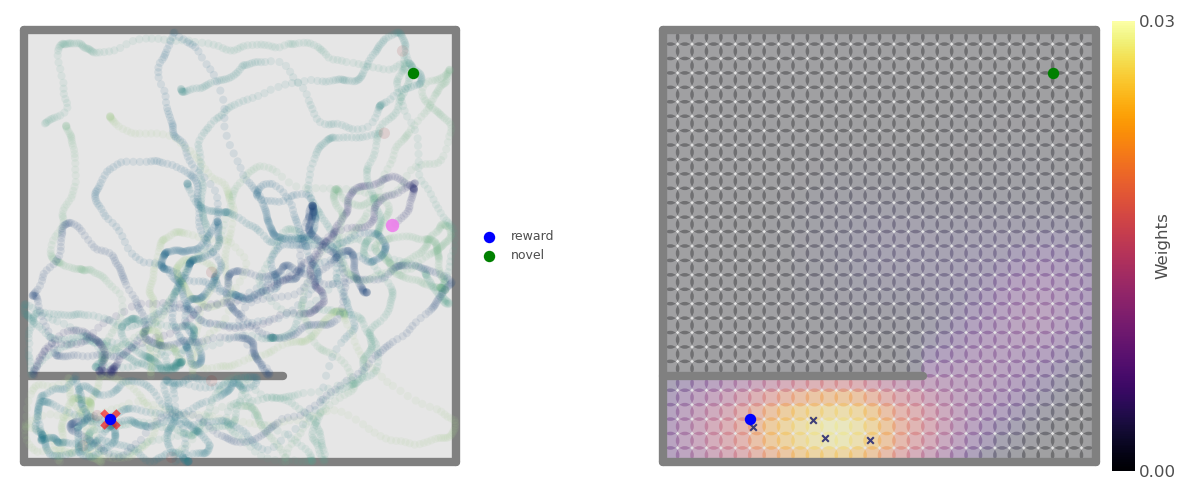

In [9]:
fig, ax1D = plt.subplots(1, 2, figsize=[8, 3])
Ag.plot_trajectories(alpha=0.1, sub_ax=ax1D[0])

plot_fcts.plot_2D_input_place_cell_weights(
    Pyrs.SomaCompartment, alpha=0.3, plot_BTSP_events=True, no_legend=True, ax=ax1D[1]
);

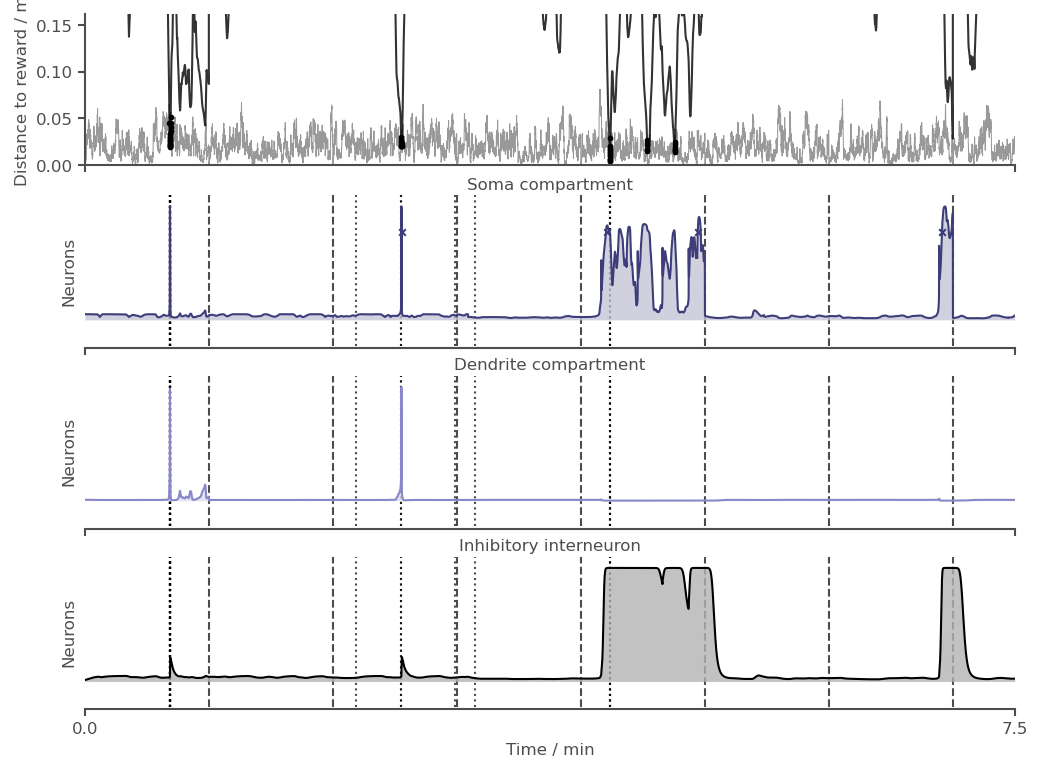

In [10]:
tol_prop_to_speed_dt = Ag.target_reached_within_tol_prop_to_speed_dt

fig, ax1D = plt.subplots(4, 1, figsize=[8, 6], sharex=True)
Ag.plot_distance_to(
    position_name="reward", 
    position=reward_location, 
    mark_below_tolerance=True, 
    tol_prop_to_speed_dt=tol_prop_to_speed_dt,
    zoom_prop=2,
    sub_ax=ax1D[0]
    )
ax1D[0].set_xlabel("")
Pyrs.plot_rate_timeseries(separate_axes=True, ax=ax1D[1:]);

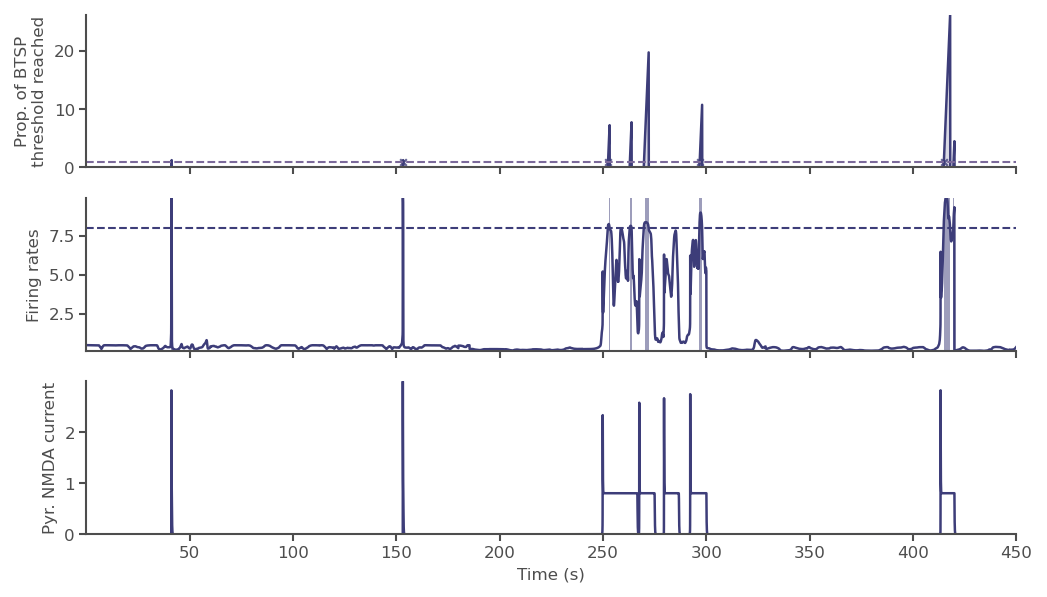

In [11]:
fig, ax1D = plt.subplots(3, 1, figsize=[8, 4.5], sharex=True)
Pyrs.SomaCompartment.plot_BTSP_ramp(axes=ax1D);

In [12]:
ANIMATE = False

In [13]:
if ANIMATE:    
    t_start = 175
    t_end = t_start + 200
    
    anim_start = time.perf_counter()
    anim = animate_util.animate(
        Ag, 
        Pyrs, 
        Pyrs_weights,
        Pyrs_weights_t,
        t_start=t_start, 
        t_end=t_end, 
        fps=5, 
        speed_up=4, 
        environment="openfield",
        embed_limit=85.0,
        autosave=False,
        )
    anim

In [14]:
if ANIMATE:
    print(f"Took {(time.perf_counter() - anim_start) / 60:.2f} min. to generate animation.")
    ratinabox.utils.save_animation(anim, "openfield_corridor_timeseries", anim_save_types=["mp4"]); # gif doesn't work well

## Add teleportation location

In [15]:
teleport_start_time = Ag.t

if Env.num_teleport_pairs == 0:
    Env.add_teleport_pairs(coord_pairs=[teleport_in_out]) # breaks the link, but OK here

Pyrs.set_learn(soma=Hebbian_learn, dend=False, inhibit=False)
Pyrs.set_BTSP_learn(soma=False, dend=False)

BTSP_started = False
num_BTSP_to_date = len(Pyrs.SomaCompartment.history["BTSP_events"])
for i in tqdm(range(15000)):
    VN.update()
    drift_velocity = None
    if Ag.target_position is not None and (Ag.target_position == VN.peak).all():
        gradV = VN.get_local_gradient(thresh_gradV=0.2)
        if gradV is not None: 
            drift_velocity = 3 * Ag.speed_mean * gradV

    Ag.update(
        drift_velocity=drift_velocity,
        drift_to_random_strength_ratio=0.2
        )
    Objs.update()
    PCs.update()
    Pyrs.update()

    if not BTSP_started and len(Ag.trajectory_df) > 2:
        Pyrs.set_BTSP_learn(soma=True, dend=False)
        BTSP_started = True

    if not i % RECORD_WEIGHTS_FREQ:
        Pyrs_weights.append(copy.deepcopy(Pyrs.SomaCompartment.inputs["PCs"]["w"]))
        Pyrs_weights_t.append(Ag.t)

num_BTSP_events = len(Pyrs.SomaCompartment.history["BTSP_events"]) - num_BTSP_to_date

print(f"{num_BTSP_events} BTSP event(s).")
Ag.log_teleportation()
Ag.trajectory_df

  0%|                                                 | 0/15000 [00:00<?, ?it/s]/home/cgillon/Documents/predhpc/predhpc/neurons/object_neurons.py:439: UserWarning: Object cell centres have been detached from the environment object locations, preventing them from being dynamically updated.
  warnings.warn(
100%|████████████████████████████████████| 15000/15000 [00:50<00:00, 294.79it/s]

8 BTSP event(s).
No teleportation events.


,start_position_x,start_position_y,start_step,start_time,stop_position_x,stop_position_y,stop_step,stop_time,num_steps_total,time_total
0,0.531423,0.283512,0,0.0,0.136878,0.979423,2000.0,60.0,2000.0,60.0
1,0.098302,0.778299,2000,60.0,0.341923,0.979423,4000.0,120.0,2000.0,60.0
2,0.047976,0.783056,4000,120.0,0.873730,0.979423,6000.0,180.0,2000.0,60.0
3,0.363621,0.862854,6000,180.0,0.835726,0.979423,8000.0,240.0,2000.0,60.0
4,0.378325,0.644871,8000,240.0,0.434448,0.979423,10000.0,300.0,2000.0,60.0
5,0.448066,0.556527,10000,300.0,0.430267,0.979423,12000.0,360.0,2000.0,60.0
6,0.793438,0.392835,12000,360.0,0.172960,0.979423,14000.0,420.0,2000.0,60.0
7,0.904293,0.645095,14000,420.0,0.358181,0.979423,16000.0,480.0,2000.0,60.0
8,0.713959,0.790059,16000,480.0,0.734408,0.979423,18000.0,540.0,2000.0,60.0
9,0.353100,0.285262,18000,540.0,0.439159,0.979423,20000.0,600.0,2000.0,60.0


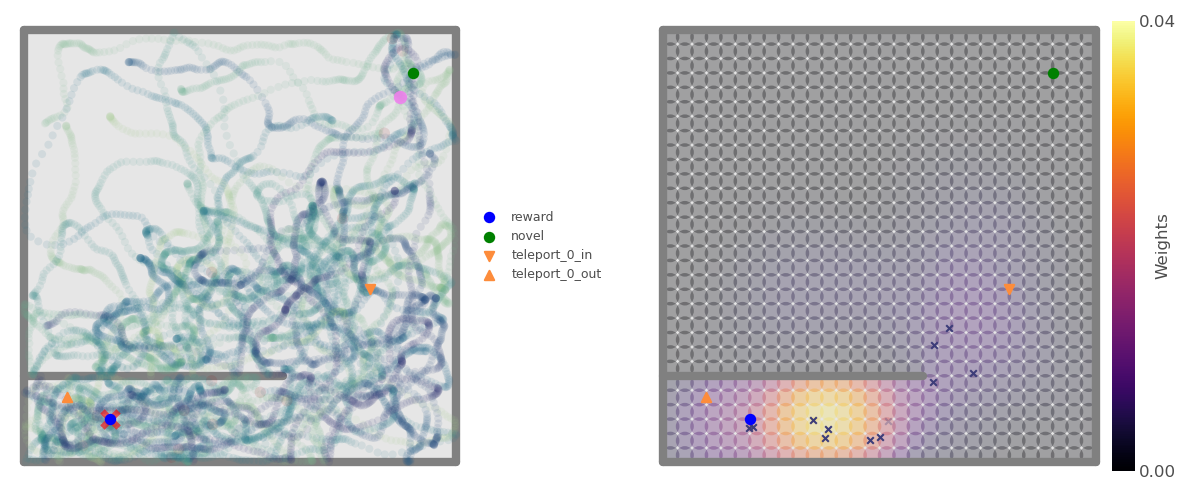

In [16]:
fig, ax1D = plt.subplots(1, 2, figsize=[8, 3])
Ag.plot_trajectories(alpha=0.1, sub_ax=ax1D[0])

plot_fcts.plot_2D_input_place_cell_weights(
    Pyrs.SomaCompartment, alpha=0.3, plot_BTSP_events=True, no_legend=True, ax=ax1D[1]
);

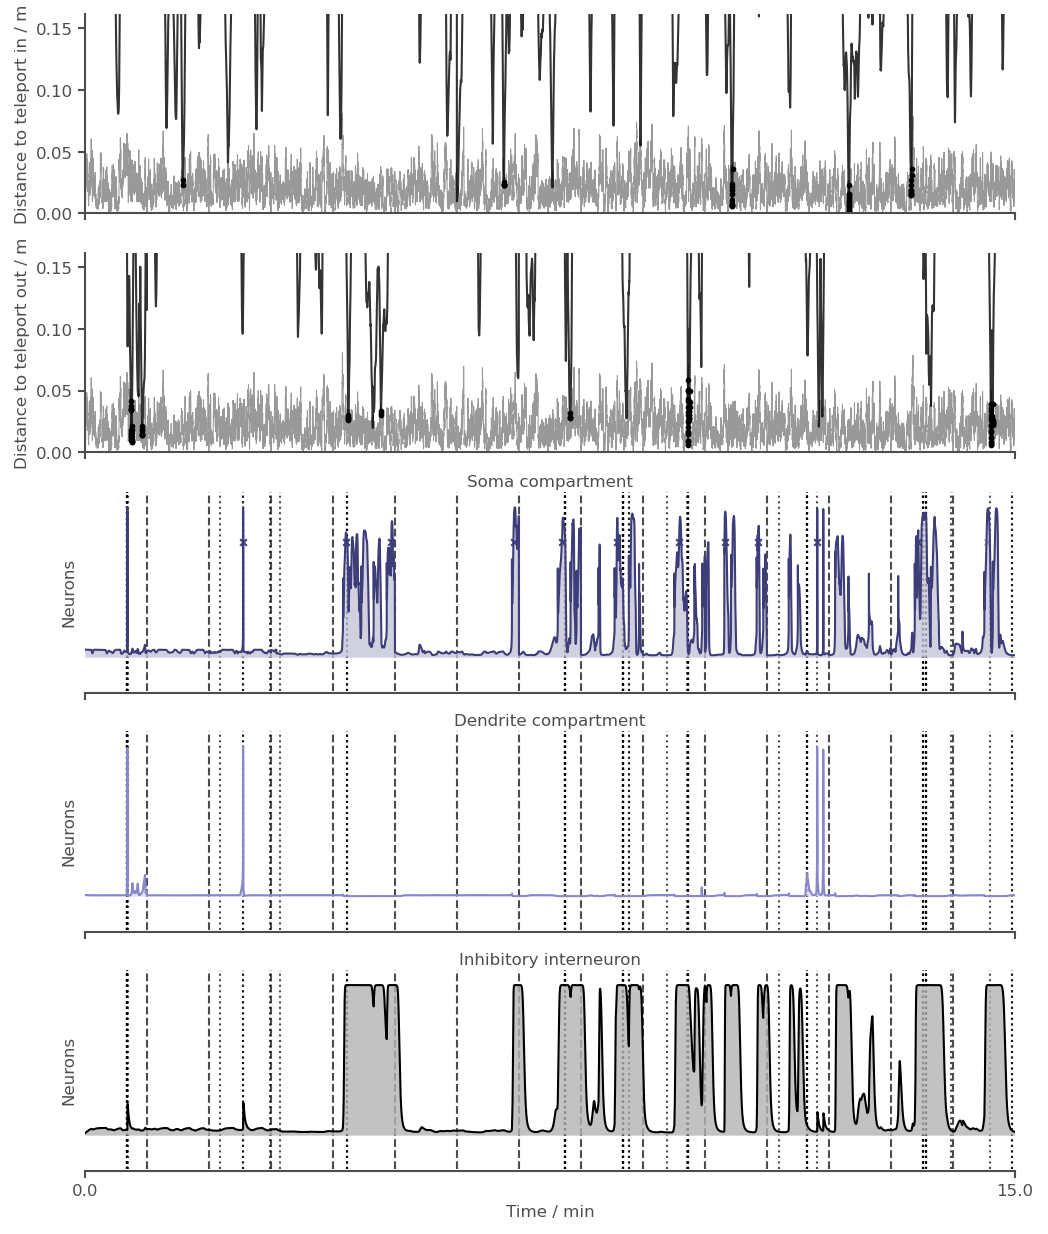

In [17]:
tol_prop_to_speed_dt = Ag.target_reached_within_tol_prop_to_speed_dt

fig, ax1D = plt.subplots(5, 1, figsize=[8, 10], sharex=True)
for i, (direc, teleport) in enumerate(zip(["in", "out"], teleport_in_out)):
    Ag.plot_distance_to(
        position_name=f"teleport {direc}", 
        position=teleport, 
        mark_below_tolerance=True, 
        tol_prop_to_speed_dt=tol_prop_to_speed_dt,
        zoom_prop=2,
        sub_ax=ax1D[i]
    )
    ax1D[i].set_xlabel("")

Pyrs.plot_rate_timeseries(separate_axes=True, ax=ax1D[2:]);

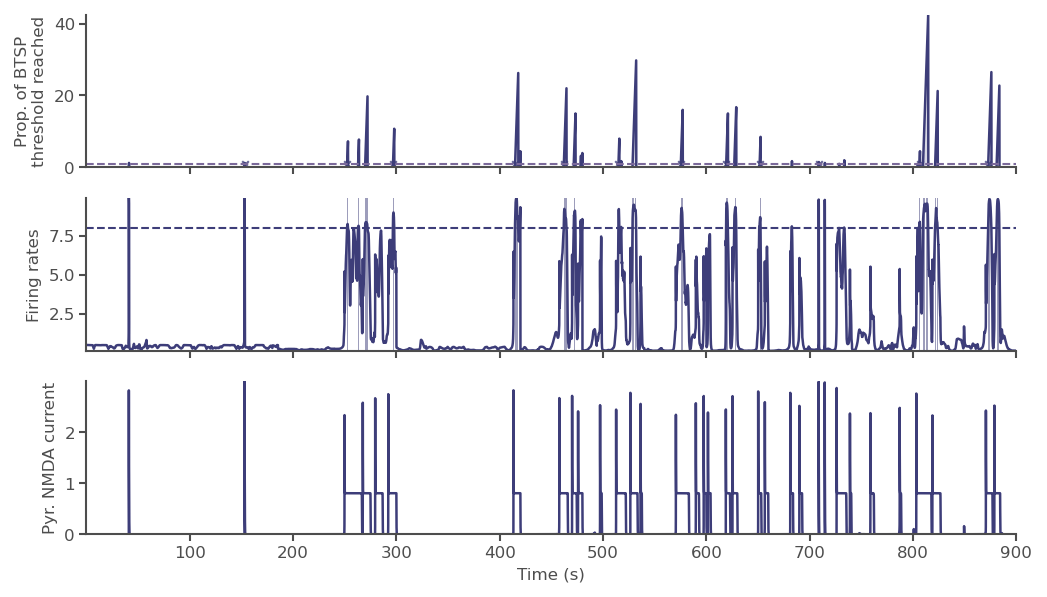

In [18]:
fig, ax1D = plt.subplots(3, 1, figsize=[8, 4.5], sharex=True)
Pyrs.SomaCompartment.plot_BTSP_ramp(axes=ax1D);

In [19]:
ANIMATE = False

In [20]:
if ANIMATE:
    t_start = 425
    t_end = t_start + 200
    
    anim_start = time.perf_counter()
    anim = animate_util.animate(
        Ag, 
        Pyrs, 
        Pyrs_weights,
        Pyrs_weights_t,
        t_start=t_start, 
        t_end=t_end, 
        fps=5, 
        speed_up=4, 
        environment="openfield",
        embed_limit=85.0,
        autosave=False,
        )
    anim

In [21]:
if ANIMATE:
    print(f"Took {(time.perf_counter() - anim_start) / 60:.2f} min. to generate animation.")
    ratinabox.utils.save_animation(anim, "openfield_corridor_timeseries_teleport", anim_save_types=["mp4"]); # gif doesn't work well

## Visualize BTSP
lr
regularization_alpha
BTSP_lr_fact
number of inputs

- density of inputs
- kernel
- gaussian over place cell activity

32 11 132.8573310344463


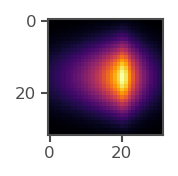

In [139]:
Is = compute_input_kernel(PC_input_density=32)
Is.shape
plt.imshow(Is.T)

(32, 32)

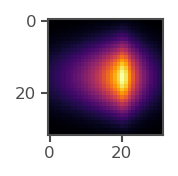

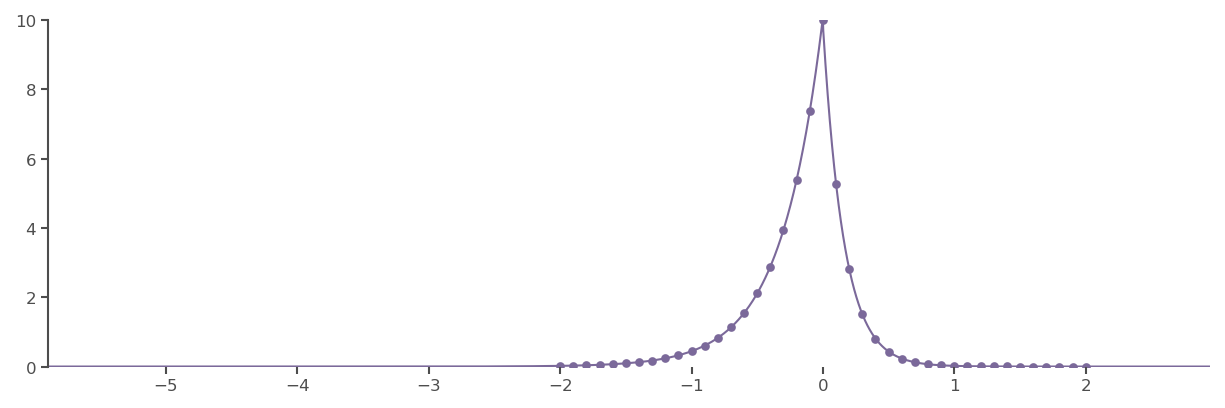

In [74]:


fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(xs, full_exp)
ax.scatter(x_coords, exp_interp, s=10)
ax.spines[["top", "right", "bottom"]].set_visible(False)

In [141]:
def compute_input_kernel(
    filter_tau=4,
    trend_tau=None,
    post_filter_tau="half", 
    post_trend_tau=None,
    max_fr=10,
    dt=0.03,
    mean_speed=0.08,
    PC_input_density=11,
    PC_width=0.20,
    env_scale=1,
    model_1D=False,
):

    # calculate BTSP kernel if following a perfectly straight trajectory, with Gaussian place cells
    post_filter_tau = learn_util.get_relative_filter_tau(
        post_filter_tau,
        filter_tau,
        )

    pre_exp = gen_util.get_exponential(
        filter_tau,
        trend_tau,
        dt=dt
    )[::-1]

    post_exp = gen_util.get_exponential(
        post_filter_tau,
        post_trend_tau,
        dt=dt
    )

    full_exp = np.concatenate([pre_exp, post_exp[1:]])
    peak_pt = len(pre_exp)
    full_exp[peak_pt] = np.mean([pre_exp[-1], post_exp[0]])
    full_exp = full_exp / full_exp.max() * max_fr

    xs = np.arange(len(full_exp)) * dt * mean_speed
    xs -= xs[peak_pt]
    coords_base = np.linspace(-env_scale, env_scale, (env_scale * 2) * PC_input_density)
    Is = np.interp(coords_base, xs, full_exp)

    # find biggest range
    max_i, max_val = 0, -np.inf
    num_pts = len(coords_base) // 2
    for i in range(num_pts):
        val = Is[i : i + num_pts].sum()
        if val > max_val:
            max_i = i
            max_val = val

    x_coords = coords_base[max_i : max_i + num_pts]
    Is = Is[max_i : max_i + num_pts]

    if not model_1D:
        y_coords = coords_base[num_pts//2:-num_pts//2]
        I_ys = np.exp(-(y_coords**2) / (2 * (PC_width**2)))
        Is = np.matmul(Is.reshape(-1, 1), I_ys.reshape(1, -1))

    return Is

In [161]:
def assess_lr_factors(
    lr=1e-4,
    filter_tau=4,
    trend_tau=None,
    post_filter_tau="half", 
    post_trend_tau=None,
    max_fr=10,
    dt=0.03,
    mean_speed=0.08,
    PC_input_density=10,
    PC_width=0.20,
    env_scale=1,
    w_init_scale=0,
    incl_bias=False,
    apply_Ojas_rule=False,
    normalize_weights_divisively=False,
    regularization_alpha=None, 
    num_updates=1,
    output_fr=None,
    activation_function=None,
    model_1D=False
):

    Is = compute_input_kernel(
        filter_tau=filter_tau,
        trend_tau=trend_tau,
        post_filter_tau=post_filter_tau, 
        post_trend_tau=post_trend_tau,
        max_fr=max_fr,
        dt=dt,
        mean_speed=mean_speed,
        PC_input_density=PC_input_density,
        PC_width=PC_width,
        env_scale=env_scale,
        model_1D=model_1D,
    )
    Is_shape = Is.shape
    Is = Is.ravel()
    
    if apply_Ojas_rule and normalize_weights_divisely:
        raise ValueError("Cannot use both Oja's rule and divisive normalization.")

    # ws
    ws = [np.full((1, len(Is)), w_init_scale).astype(float)]

    # b
    b = None
    if incl_bias:
        b = np.zeros(1).astype(float)

    # activation params
    if activation_function is None:
        activation_function = params_util.LINEAR_SIGMOID_ACTIVATION_PARAMS
    if isinstance(activation_function, dict):
        activation_params = copy.deepcopy(activation_function)
        activation = activation_params["activation"]
        activation_function = lambda x, deriv=False : rutils.activate(x, activation, deriv=False, other_args=activation_params)    

    # O
    if output_fr is None:
        V = np.dot(ws, Is)
        O = activation_function(V)
    else:
        O = np.asarray([output_fr])

    records = {
        "ws": [copy.deepcopy(ws[0]).reshape(Is_shape)],
        "O": [copy.deepcopy(O)],
    }
    if incl_bias:
        records["b"] = [copy.deepcopy(b)]

    for _ in range(num_updates):
        if apply_Ojas_rule:
            learn_util.perform_Oja_update_([Is], ws, O, lr=lr, b=b, alpha=alpha)
        elif normalize_weights_divisively:  # type: ignore[attr-defined]
            learn_util.perform_divisively_normalized_Hebbian_update_(
                [Is], ws, O, lr=lr, b=b, p=self.p, alpha=alpha
            )
        else:
            learn_util.perform_Hebbian_update_([Is], ws, O, lr=lr, b=b)
        records["ws"].append(copy.deepcopy(ws[0]).reshape(Is_shape))
        records["O"].append(copy.deepcopy(O))
        if incl_bias:
            records["b"].append(copy.deepcopy(b))

    return records
    

In [165]:
records = assess_lr_factors(
    lr=1e-4 * 20,
    regularization_alpha=0.4,
    PC_input_density=10,
    env_scale=4,
    num_updates=3
)

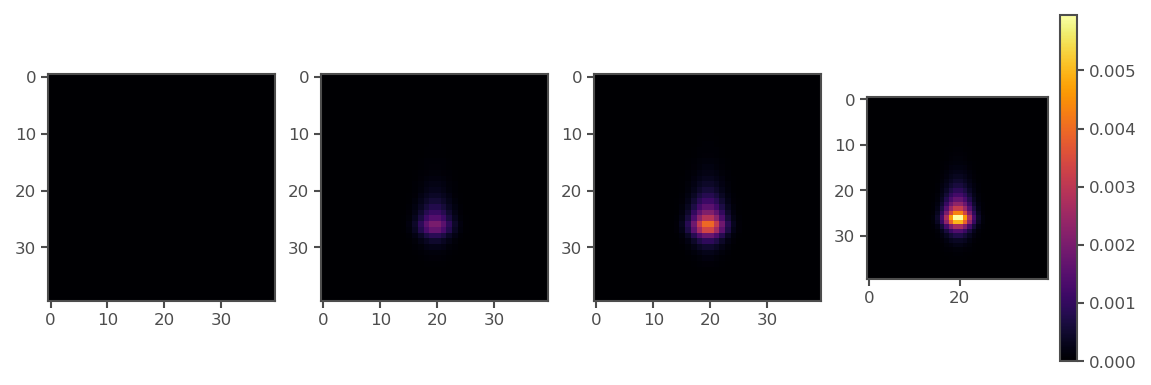

In [172]:
fig, ax = plt.subplots(1, 4, figsize=(9, 3))
vmin = 0
vmax = np.max(records["ws"])
for i, w in enumerate(records["ws"]):
    im = ax[i].imshow(w, vmin=vmin, vmax=vmax)
fig.colorbar(im)